# Graham & Dodd 防御型 10 条选股 —— A股 季度回测 (2023-01 · 至今)

本 notebook 完整实现并回测格雷厄姆/雷亚的经典防御型选股框架：

- **资产池**: 清单包含当前上市与已退市；无行情/财报数据的标的会被排除并单独报告，不能宣称完全消除幸存者偏差
- **无数据穿越**: 财报与分红只用「公告日期 ≤ 信号日」的记录; 信号在收盘形成、下一交易日收盘成交
- **频率**: 每季度首日产生信号，下一交易日成交；最后一期持有至 END
- **起点资金**: 1,000,000 元, 空仓起步, 可持币
- **仓位规则**: 候选等权买入; 上限 30 只; 单只最大仓位 15%; **单行业 ≤ 25% 且 ≤ 4 只**;
  100 股整手; 无候选→全现金
- **防御纪律** (本版新增, 贴近格雷厄姆防御型):
  1. **硬性门禁**——市值 ≥ 当日全A可交易市值 30% 分位、近5年报连续盈利(≤1次为负且最近为正)、
     近5财年现金分红 ≥4 年; 三者独立于 10 条件评分, 任一不满足即不可纳入;
  2. **估值仪表盘现金缓冲**——以全部A股平均PE相对自身10年历史的百分位调整权益仓位:
     低分位(<50%)满仓, 高分位(≥85%)降至 40%; 高位时按"安全边际最差优先"主动降仓至目标权益, 回收现金;
  3. **两档卖出**——持有中跌破卖出下限(≥5/10)或盈利/分红门禁失效才卖, 避免季度全换手的成本损耗.
- **交易成本**: 佣金万3双向(单笔最低5元) + 卖出印花税 + 过户费；使用原始价格，分红按除权日显式入账并按持有期扣税
- **行业门禁**: 行业未知的标的不进入组合，避免缺失标签绕过行业集中度上限；当前名称可排除当前 ST，但历史 ST 状态仍需点时证券状态数据

## 10 条选股条件 (与判定口径)

| # | 条件 | 判定口径 |
|---|---|---|
| 1 | 收益价格比 ≥ 2×AAA | E/P = TTM归母净利 ÷ 最新股本 ÷ 收盘价; AAA=中债10年期国债收益率(代理) |
| 2 | PE ≤ 60%×市场5年均PE | 当前PE_TTM ≤ 0.6 × (过去5年全部A股等权平均PE的均值) |
| 3 | 股息率 ≥ 2/3×AAA | 最近一次已实施方案(公告≤D, 年报)每股现金股息 ÷ 收盘价 |
| 4 | 价格 ≤ 2/3 有形净资产 | 有形净资产 = 归母净资产 − 无形资产 − 商誉; ÷当前股本 |
| 5 | 价格 ≤ 2/3 净流动资产 | NCA = 流动资产合计 − 负债合计; ÷当前股本 |
| 6 | 负债/净资产 < 1 | 负债合计 ÷ 归母净资产 |
| 7 | 流动比率 ≥ 2 | 流动资产合计 ÷ 流动负债合计 |
| 8 | 总负债 < 2×NCA | 负债合计 ÷ (2×NCA) < 1 |
| 9 | 十年EPS CAGR > 7% | 年报基本EPS, 过去十年 CAGR |
| 10 | 十年中下滑年 ≤ 2 | 年报EPS同比负增长财年数 ≤ 2 |

> ### 纳入口径: 至少 8/10，且 c1/c2/c3/c6/c7/c8/c9/c10 八项核心防御条件全部满足
> c4/c5 是更严格的净净股价格条件，作为额外安全边际而非防御型必备条件。
> 另通过市值、近五年盈利、近五年分红、当前 ST 排除等门禁。
> 满 10/10 的公司单独标注。9/10 或 10/10 属于"极端低估时刻"才可能出现的形态。


In [1]:
import sys, os, json
_ROOT = os.getcwd()
for _ in range(4):
    if os.path.exists(os.path.join(_ROOT, 'strategy', 'graham_dodd.py')):
        break
    _ROOT = os.path.dirname(_ROOT)
os.chdir(_ROOT)
sys.path.insert(0, _ROOT)
import pandas as pd, numpy as np
import warnings; warnings.filterwarnings('ignore')
from strategy.graham_dodd import (load_universe, load_balance, load_profit,
    load_dividend, load_market, load_10y, load_all_a_pe, load_index,
    r10y, market_avg_pe_5y, snapshot, evaluate, COND_NAMES, GATE_NAMES,
    rebalance_dates, screen_all, GrahamBacktest, perf_metrics,
    market_gauge, target_equity_weight, FUNNEL,
    START, END, MIN_PASS_DEF,
    SIZE_QUANTILE, SELL_FLOOR, SECTOR_WEIGHT_CAP, SECTOR_MAX_STOCKS,
    GAUGE_LO_PCT, GAUGE_HI_PCT, GAUGE_LO_WEIGHT)

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)
INITIAL_CAPITAL = 1_000_000.0
MIN_PASS = MIN_PASS_DEF
print('防御参:', f'MIN_PASS={MIN_PASS}', f'SELL_FLOOR={SELL_FLOOR}',
      f'SIZE_QUANTILE={SIZE_QUANTILE}', f'SECTOR_CAP={SECTOR_WEIGHT_CAP:.0%}/{SECTOR_MAX_STOCKS}只',
      f'GAUGE={GAUGE_LO_PCT:.0%}->{GAUGE_HI_PCT:.0%}(w={GAUGE_LO_WEIGHT:.0%})')

防御参: MIN_PASS=8 SELL_FLOOR=5 SIZE_QUANTILE=0.3 SECTOR_CAP=25%/4只 GAUGE=50%->85%(w=40%)


## 1. 数据现状核查

In [2]:
uni = load_universe()
has_bal = sum(1 for c in uni['code'] if load_balance(c) is not None)
has_pro = sum(1 for c in uni['code'] if load_profit(c) is not None)
has_div = sum(1 for c in uni['code'] if load_dividend(c) is not None)
has_mkt = sum(1 for c in uni['code'] if load_market(c, qfq=False) is not None)
rbs = rebalance_dates()
print(f'资产池(全部A股): {len(uni)} 只  (当前 {int((uni.kind=="current").sum())} / 退市 {int((uni.kind=="delisted").sum())})')
print(f'资产负债表覆盖: {has_bal} ({has_bal/len(uni):.1%})  利润表覆盖: {has_pro} ({has_pro/len(uni):.1%})')
print(f'分红数据覆盖: {has_div}  行情覆盖(不复权): {has_mkt}')
print(f'调仓日: {[d.date().isoformat() for d in rbs]}')
print(f'中债10Y国债(AAA代理)区间: {load_10y().index.min().date()} ~ {load_10y().index.max().date()}, 行数 {len(load_10y())}')
print(f'全部A股PE区间: {load_all_a_pe().index.min().date()} ~ {load_all_a_pe().index.max().date()}, 行数 {len(load_all_a_pe())}')

资产池(全部A股): 5904 只  (当前 5543 / 退市 361)
资产负债表覆盖: 4283 (72.5%)  利润表覆盖: 4281 (72.5%)
分红数据覆盖: 4276  行情覆盖(不复权): 4305
调仓日: ['2023-01-03', '2023-04-03', '2023-07-03', '2023-10-09', '2024-01-02', '2024-04-01', '2024-07-01', '2024-10-08', '2025-01-02', '2025-04-01', '2025-07-01', '2025-10-09', '2026-01-05', '2026-04-01', '2026-07-01']
中债10Y国债(AAA代理)区间: 1990-12-19 ~ 2026-08-14, 行数 9321
全部A股PE区间: 2005-01-05 ~ 2026-08-14, 行数 5245


## 2. 筛选与点检示例

对首个信号日做一次全市场筛选, 展示纳入口径 (≥8/10 且核心条件齐全) 的全部候选名单与逐条件明细。


In [3]:
D = rbs[0]
r = r10y(D); mpe = market_avg_pe_5y(D)
print(f'调仓日 {D.date()}  中债10Y(AAA代理)={r:.2%}  全部A股5年均PE={mpe:.2f}')
print(f'  估值仪表盘: 全A平均PE分位={market_gauge(D):.0%}  目标权益仓位={target_equity_weight(market_gauge(D)):.0%}')
print(f'  条件1门槛(E/P≥2×AAA): {2*r:.2%}  条件3门槛(2/3×AAA): {(2/3)*r:.2%}')
print(f'  条件2门槛(PE≤60%×5年均PE): {0.6*mpe:.2f}')
passed = screen_all(D, min_pass=MIN_PASS)
print(f'纳入候选 (≥8/10 + 核心条件 + 门禁): {len(passed)} 只')
for s, ev in passed:
    marks = ' '.join(f'{k.split("c")[1]}' + ('✓' if ev.detail[k][0] else '✗')
                     for k in list(ev.detail))
    gt = ','.join(k for k, v in ev.gates.items() if v[0]) or '无门禁通过'
    print(f'  {s.code} {s.name}  价格{s.price:8.2f}  通过{ev.npass}/10 门禁[{gt}]  [{marks}]')
full = [s for s, ev in passed if ev.npass == 10]
print(f'其中 满 10/10: {len(full)} 只', ' '.join(s.name for s in full) if full else '')

调仓日 2023-01-03  中债10Y(AAA代理)=2.82%  全部A股5年均PE=47.87
  估值仪表盘: 全A平均PE分位=20%  目标权益仓位=100%
  条件1门槛(E/P≥2×AAA): 5.65%  条件3门槛(2/3×AAA): 1.88%
  条件2门槛(PE≤60%×5年均PE): 28.72


纳入候选 (≥8/10 + 核心条件 + 门禁): 4 只
  002233 塔牌集团  价格    7.18  通过8/10 门禁[earnings,dividend,size]  [1✓ 2✓ 3✓ 4✗ 5✗ 6✓ 7✓ 8✓ 9✓ 10✓]
  600479 千金药业  价格   10.01  通过8/10 门禁[earnings,dividend,size]  [1✓ 2✓ 3✓ 4✗ 5✗ 6✓ 7✓ 8✓ 9✓ 10✓]
  600566 济川药业  价格   27.96  通过8/10 门禁[earnings,dividend,size]  [1✓ 2✓ 3✓ 4✗ 5✗ 6✓ 7✓ 8✓ 9✓ 10✓]
  600585 海螺水泥  价格   27.71  通过8/10 门禁[earnings,dividend,size]  [1✓ 2✓ 3✓ 4✗ 5✗ 6✓ 7✓ 8✓ 9✓ 10✓]
其中 满 10/10: 0 只 


### 候选与接近候选明细

以下按满足条件数从高到低列出首个调仓日的前若干候选, 并逐条核对未满足项
(✓=满足, ✗=未满足; 数值为该条件当前值/要求)。


In [4]:
def audit_near(D, top=12):
    r = r10y(D); mpe = market_avg_pe_5y(D)
    rows = []
    for c in uni['code']:
        s = snapshot(c, D)
        if not s.tradable:
            continue
        ev = evaluate(s, D, r=r, mpe=mpe)
        rows.append((s, ev, ev.npass))
    rows.sort(key=lambda x: (-x[2], x[0].price))
    return rows[:top]

aud = audit_near(rbs[0], top=12)
for s, ev, np_ in aud:
    marks = ' '.join(f'{k.split("c")[1]}' + ('✓' if ev.detail[k][0] else '✗')
                     for k in list(ev.detail))
    print(f'{s.code} {s.name:6s} 价格{s.price:8.2f}  通过{np_}/10  [{marks}]')
    for k in list(ev.detail)[:10]:
        ok, cur, req = ev.detail[k]
        if not ok:
            print(f'      {k}: ✗ {cur} vs {req}')

002027 分众传媒   价格    6.81  通过8/10  [1✓ 2✓ 3✓ 4✓ 5✓ 6✓ 7✓ 8✓ 9✗ 10✗]
      c9: ✗ 2.774000e-01 vs CAGR>7%
      c10: ✗ 5年 vs ≤2
002233 塔牌集团   价格    7.18  通过8/10  [1✓ 2✓ 3✓ 4✗ 5✗ 6✓ 7✓ 8✓ 9✓ 10✓]
      c4: ✗ 7.2  vs ≤5.8
      c5: ✗ 7.2 vs ≤2.0
002270 华明装备   价格    7.87  通过8/10  [1✓ 2✓ 3✓ 4✓ 5✗ 6✓ 7✓ 8✓ 9✓ 10✗]
      c5: ✗ 7.9 vs ≤5.4
      c10: ✗ 5年 vs ≤2
600479 千金药业   价格   10.01  通过8/10  [1✓ 2✓ 3✓ 4✗ 5✗ 6✓ 7✓ 8✓ 9✓ 10✓]
      c4: ✗ 10.0  vs ≤2.9
      c5: ✗ 10.0 vs ≤2.4
601858 中国科传   价格   11.32  通过8/10  [1✓ 2✓ 3✓ 4✗ 5✗ 6✓ 7✓ 8✓ 9✓ 10✓]
      c4: ✗ 11.3  vs ≤3.8
      c5: ✗ 11.3 vs ≤1.6
600585 海螺水泥   价格   27.71  通过8/10  [1✓ 2✓ 3✓ 4✗ 5✗ 6✓ 7✓ 8✓ 9✓ 10✓]
      c4: ✗ 27.7  vs ≤19.5
      c5: ✗ 27.7 vs ≤7.7
600566 济川药业   价格   27.96  通过8/10  [1✓ 2✓ 3✓ 4✗ 5✗ 6✓ 7✓ 8✓ 9✓ 10✓]
      c4: ✗ 28.0  vs ≤14.6
      c5: ✗ 28.0 vs ≤9.5
603444 吉比特    价格  323.50  通过8/10  [1✓ 2✓ 3✓ 4✗ 5✗ 6✓ 7✓ 8✓ 9✓ 10✓]
      c4: ✗ 323.5  vs ≤41.3
      c5: ✗ 323.5 vs ≤18.9
601000 唐山港    价格    2.73  通过7/10  [1✓ 2✓ 3✓ 4✗ 5✗ 

## 3. 季度回测执行

In [5]:
# 全市场筛选整个日历(一次), 供回测与各阶段说明复用; (s, ev) 含门禁明细
screening_map = {}
for d in rbs:
    screening_map[d] = screen_all(d, min_pass=MIN_PASS)

bt = GrahamBacktest(initial_capital=INITIAL_CAPITAL)
nav, trades, dates = bt.run(rbs, screening_map=screening_map, end=END)
print(f'回测完成: {len(trades)} 笔交易, 净值点数 {len(nav)}')
print(f'期末净值: {nav.iloc[-1]:,.2f} 元  ({(nav.iloc[-1]/INITIAL_CAPITAL-1):+.2%})')

  2023-01-04 候选4 目标权益100% 现金缓冲后买入4只
  2023-04-04 候选5 目标权益100% 现金缓冲后买入1只
  2023-07-04 候选8 目标权益100% 现金缓冲后买入4只
  2023-10-10 候选8 目标权益100% 现金缓冲后买入1只
  2024-01-03 候选11 目标权益100% 现金缓冲后买入0只
  2024-04-02 候选12 目标权益100% 现金缓冲后买入0只


  2024-07-02 候选21 目标权益100% 现金缓冲后买入0只
  2024-10-09 候选14 目标权益89% 现金缓冲后买入2只
  2025-01-03 候选29 目标权益99% 现金缓冲后买入1只


  2025-04-02 候选28 目标权益72% 现金缓冲后买入2只
  2025-07-02 候选33 目标权益60% 现金缓冲后买入1只
  2025-10-10 候选29 目标权益44% 现金缓冲后买入1只


  2026-01-06 候选26 目标权益42% 现金缓冲后买入2只
  2026-04-02 候选21 目标权益40% 现金缓冲后买入3只
  2026-07-02 候选24 目标权益40% 现金缓冲后买入5只


回测完成: 45 笔交易, 净值点数 865
期末净值: 1,064,099.15 元  (+6.41%)


## 4. 每个阶段的调仓动作说明

下表按调仓日列出: 信号到期时的全市场通过名单、买入/卖出动作、股数与成交价、
当季贡献仓位、以及带成本的现金/净值。


In [6]:
TRADE_COLS = ['date','code','name','action','shares','price','proceeds','fee','reason']
trades_df = pd.DataFrame(trades, columns=TRADE_COLS)
def period_table(d, bt):
    t = trades_df[trades_df['date'] == d]
    out = []
    for _, x in t.iterrows():
        out.append({'日期': d.date(), '代码': x.code, '名称': x['name'],
                    '动作': ('买入' if x.action=='buy' else '卖出'),
                    '股数': int(x.shares) if x.shares and x.shares>0 else '—',
                    '成交价': f"{x.price:.2f}" if np.isfinite(x.price) else '—',
                    '金额': f"{x.proceeds:,.0f}",
                    '费用': f"{x.fee:.2f}",
                    '理由': x.reason})
    return pd.DataFrame(out)

lines = []
for d in rbs:
    s_all = [s for s, _ in screening_map.get(d, [])]
    df = period_table(d, bt)
    lines.append(f"### 调仓日 {d.date()}")
    lines.append(f"- 全市场通过防御核心条件: **{len(s_all)}** 只")
    names = '、'.join(f"{s.code} {s.name}" for s in s_all) or '无(继续持币)'
    lines.append(f"- 通过名单: {names}")
    if df.empty:
        lines.append("- 本季无买卖调仓。")
    else:
        lines.append("")
        lines.append(df.to_string(index=False))
    navD = bt.nav_curve.get(next((p['date'] for p in bt.periods if p.get('signal_date') == d), d), np.nan)
    lines.append(f"- 当季期末净值: {navD:,.2f} 元 `(`现金或持仓市值合计`)`")
    lines.append("")
print('\n'.join(lines))

### 调仓日 2023-01-03
- 全市场通过防御核心条件: **4** 只
- 通过名单: 002233 塔牌集团、600479 千金药业、600566 济川药业、600585 海螺水泥
- 本季无买卖调仓。
- 当季期末净值: 999,845.75 元 `(`现金或持仓市值合计`)`

### 调仓日 2023-04-03
- 全市场通过防御核心条件: **5** 只
- 通过名单: 000026 飞亚达、002233 塔牌集团、600479 千金药业、600566 济川药业、600585 海螺水泥
- 本季无买卖调仓。
- 当季期末净值: 1,037,671.63 元 `(`现金或持仓市值合计`)`

### 调仓日 2023-07-03
- 全市场通过防御核心条件: **8** 只
- 通过名单: 000026 飞亚达、000650 仁和药业、002415 海康威视、002677 浙江美大、600511 国药股份、600566 济川药业、600585 海螺水泥、600867 通化东宝
- 本季无买卖调仓。
- 当季期末净值: 1,041,717.13 元 `(`现金或持仓市值合计`)`

### 调仓日 2023-10-09
- 全市场通过防御核心条件: **8** 只
- 通过名单: 000026 飞亚达、000650 仁和药业、000915 华特达因、002328 新朋股份、002677 浙江美大、600566 济川药业、600585 海螺水泥、600867 通化东宝
- 本季无买卖调仓。
- 当季期末净值: 1,003,171.12 元 `(`现金或持仓市值合计`)`

### 调仓日 2024-01-02
- 全市场通过防御核心条件: **11** 只
- 通过名单: 000026 飞亚达、000650 仁和药业、000733 振华科技、000915 华特达因、002328 新朋股份、002677 浙江美大、300109 新开源、300327 中颖电子、600566 济川药业、600585 海螺水泥、600867 通化东宝
- 本季无买卖调仓。
- 当季期末净值: 1,004,273.12 元 `(`现金或持仓市值合计`)`

### 调仓日 2024-04-01
- 全市场通过防御核心条件: **12** 只
- 通过名单: 000650 仁

## 5. 防御性校验: 门禁漏斗 · 行业分布 · 现金缓冲

针对上一版(始终满仓、集中于传媒/出版等单一主题)暴露的高波动与深回撤, 本版加入三道防御纪律:
**(a) 硬性门禁**、**(b) 估值仪表盘的现金缓冲**、**(c) 单行业封顶 + 两档卖出**。以下逐项核查。


In [7]:
# (a) 门禁漏斗: 每个调仓日一次全市场扫描的统计数据
funnel = pd.DataFrame([{'日期': d.date(), '可交易': FUNNEL.get(d, {}).get('tradable', 0),
                        '通过防御核心': FUNNEL.get(d, {}).get('score', 0),
                        '+分红门禁': FUNNEL.get(d, {}).get('div', 0),
                        '+盈利门禁': FUNNEL.get(d, {}).get('earn', 0),
                        '+市值门禁(终选)': FUNNEL.get(d, {}).get('final', 0)} for d in rbs])
print('门禁漏斗 (各调仓日通过数):')
print(funnel.to_string(index=False))

门禁漏斗 (各调仓日通过数):
        日期  可交易  通过防御核心  +分红门禁  +盈利门禁  +市值门禁(终选)
2023-01-03 2241       4      4      4          4
2023-04-03 2243       5      5      5          5
2023-07-03 2240       8      8      8          8
2023-10-09 2242       9      9      9          8
2024-01-02 2243      11     11     11         11
2024-04-01 2244      15     13     15         12
2024-07-01 2243      24     22     24         21
2024-10-08 2240      16     15     16         14
2025-01-02 2235      33     30     33         29
2025-04-01 2242      33     31     33         28
2025-07-01 2241      38     37     38         33
2025-10-09 2249      33     32     33         29
2026-01-05 2266      30     29     30         26
2026-04-01 2269      25     24     25         21
2026-07-01 2284      28     26     28         24


In [8]:
# (b) 估值仪表盘 与 实际现金缓冲 (每调仓日)
gauge_rows = []
for p in bt.periods:
    mark = bt.nav_curve.get(p['date'], np.nan)
    gauge_rows.append({'日期': p['date'].date(), '全A平均PE分位': f"{p['gauge']:.0%}",
                       '目标权益仓位': f"{p['eq_target']:.0%}",
                       '实际权益占比': f"{1 - p['cash']/mark:.0%}" if np.isfinite(mark) and mark>0 else '—',
                       '候选(核心条件+门禁)': p['candidates']})
print('现金/估值仪表盘时间线:')
print(pd.DataFrame(gauge_rows).to_string(index=False))
hi_periods = sum(1 for p in bt.periods if p['gauge'] > GAUGE_LO_PCT)
print(f'\n处于仪表盘高位(>50%分位), 触发现金缓冲的调仓次数: {hi_periods}/{len(bt.periods)}')

现金/估值仪表盘时间线:
        日期 全A平均PE分位 目标权益仓位 实际权益占比  候选(核心条件+门禁)
2023-01-04      20%   100%    50%            4
2023-04-04      41%   100%    67%            5
2023-07-04      41%   100%   100%            8
2023-10-10      28%   100%   100%            8
2024-01-03      43%   100%   100%           11
2024-04-02      23%   100%   100%           12
2024-07-02       7%   100%   100%           21
2024-10-09      57%    89%    94%           14
2025-01-03      51%    99%   100%           29
2025-04-02      66%    72%    76%           28
2025-07-02      73%    60%    64%           33
2025-10-10      83%    44%    47%           29
2026-01-06      84%    42%    45%           26
2026-04-02      86%    40%    42%           21
2026-07-02      87%    40%    41%           24

处于仪表盘高位(>50%分位), 触发现金缓冲的调仓次数: 8/15


In [9]:
# (c) 持仓行业分布 (每调仓日, 按当季投资市值的前 5 行业)
for p in bt.periods:
    mark = bt.nav_curve.get(p['date'], np.nan)
    inds = sorted((k for k in p['industry'].items() if k[0]), key=lambda kv: -kv[1])[:5]
    share = f"{sum(v for _, v in inds) / mark:.0%}" if np.isfinite(mark) and mark > 0 else '—'
    top = '、'.join(f"{k}({v / mark:.0%})" for k, v in inds) if np.isfinite(mark) and mark > 0 else '·'
    print(f"{p['date'].date()}: 前5行业占净值 {share}  -> {top}")

2023-01-04: 前5行业占净值 50%  -> 生物制药(25%)、水泥行业(25%)
2023-04-04: 前5行业占净值 63%  -> 生物制药(24%)、水泥行业(24%)、商业百货(15%)
2023-07-04: 前5行业占净值 96%  -> 生物制药(25%)、商业百货(25%)、水泥行业(24%)、家电行业(15%)、仪器仪表(7%)
2023-10-10: 前5行业占净值 100%  -> 生物制药(26%)、商业百货(26%)、水泥行业(25%)、家电行业(15%)、仪器仪表(8%)
2024-01-03: 前5行业占净值 99%  -> 生物制药(26%)、商业百货(26%)、水泥行业(25%)、家电行业(15%)、仪器仪表(8%)
2024-04-02: 前5行业占净值 97%  -> 生物制药(25%)、商业百货(25%)、水泥行业(24%)、家电行业(15%)、仪器仪表(7%)
2024-07-02: 前5行业占净值 101%  -> 生物制药(26%)、商业百货(26%)、水泥行业(25%)、家电行业(16%)、仪器仪表(8%)
2024-10-09: 前5行业占净值 96%  -> 商业百货(26%)、水泥行业(25%)、生物制药(22%)、家电行业(16%)、仪器仪表(8%)
2025-01-03: 前5行业占净值 99%  -> 商业百货(27%)、水泥行业(26%)、生物制药(22%)、家电行业(16%)、仪器仪表(8%)
2025-04-02: 前5行业占净值 76%  -> 商业百货(26%)、家电行业(15%)、水泥行业(15%)、生物制药(13%)、仪器仪表(8%)
2025-07-02: 前5行业占净值 58%  -> 商业百货(24%)、家电行业(14%)、生物制药(13%)、仪器仪表(7%)、机械行业(0%)
2025-10-10: 前5行业占净值 41%  -> 家电行业(14%)、商业百货(14%)、仪器仪表(7%)、生物制药(6%)
2026-01-06: 前5行业占净值 38%  -> 家电行业(14%)、商业百货(14%)、仪器仪表(7%)、生物制药(3%)
2026-04-02: 前5行业占净值 44%  -> 生物制药(18%)、家电行业(14%)、仪器仪表(7%)、酿酒行业(5%)、电器

## 6. 净值曲线与基准对比

In [10]:
base = nav / INITIAL_CAPITAL
hs = load_index('000300').loc[base.index[0]:base.index[-1], 'close']; hs = hs/hs.iloc[0]
zz = load_index('000906').loc[base.index[0]:base.index[-1], 'close']; zz = zz/zz.iloc[0]
comp = pd.DataFrame({'本策略(含成本)': base,
                     '沪深300': hs, '中证800': zz}).dropna(how='all')
comp = comp.ffill().dropna(subset=['本策略(含成本)'])
comp.tail(8).round(4)

,本策略(含成本),沪深300,中证800
2026-07-22,1.0496,1.2117,1.2356
2026-07-23,1.0666,1.2145,1.2369
2026-07-24,1.0429,1.1943,1.2132
2026-07-27,1.0528,1.2079,1.2314
2026-07-28,1.0453,1.1738,1.1941
2026-07-29,1.0519,1.1817,1.2035
2026-07-30,1.0517,1.1687,1.1846
2026-07-31,1.0641,1.1786,1.1999


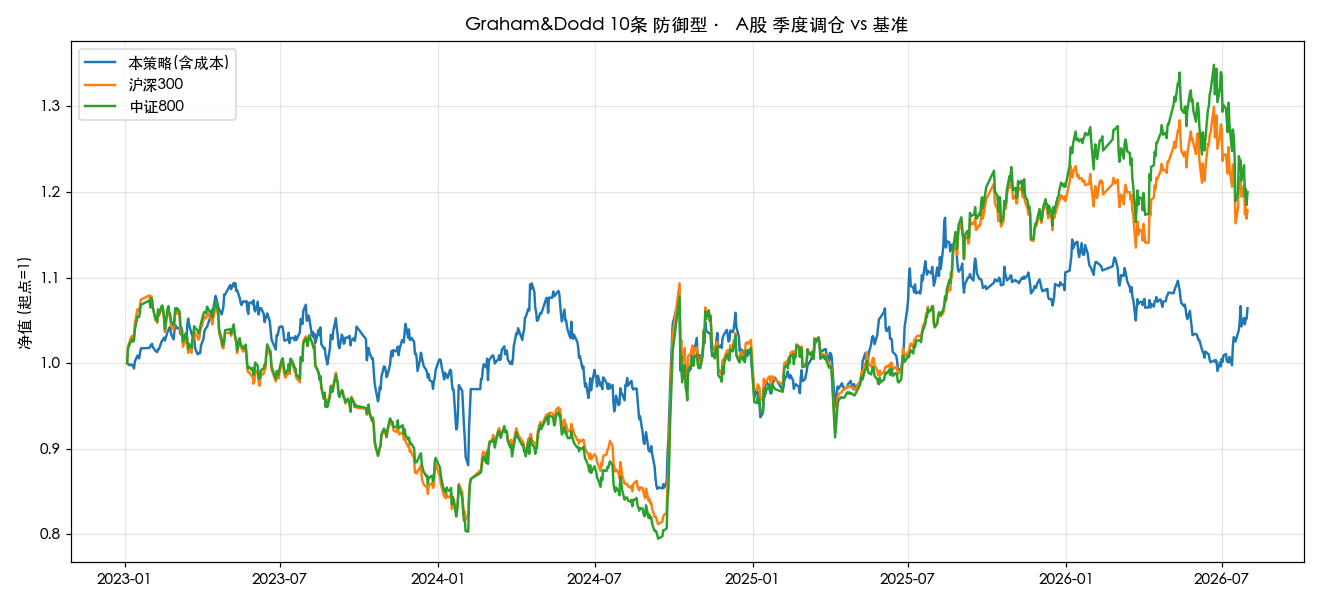

净值对比图: reports/generated/graham_dodd/nav_compare.png


In [11]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from IPython.display import Image, display
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'STHeiti', 'Songti SC']
plt.rcParams['axes.unicode_minus'] = False
os.makedirs('reports/generated/graham_dodd', exist_ok=True)
fig, ax = plt.subplots(figsize=(12, 5.5))
for c in comp.columns:
    ax.plot(comp[c], label=c, linewidth=1.6)
ax.set_title('Graham&Dodd 10条 防御型 · A股 季度调仓 vs 基准')
ax.set_ylabel('净值 (起点=1)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
img = 'reports/generated/graham_dodd/nav_compare.png'
fig.savefig(img, dpi=110)
plt.close(fig)
comp.to_csv('reports/generated/graham_dodd/nav_compare.csv')
display(Image(filename=img))
print('净值对比图: reports/generated/graham_dodd/nav_compare.png')

## 7. 绩效口径

In [12]:
m = perf_metrics(nav)
labels = {'total_return':'累计收益','annual_return':'年化收益','annual_vol':'年化波动',
          'sharpe':'夏普','max_drawdown':'最大回撤','win_rate':'日胜率'}
print(f"{'期末权益':<12} {nav.iloc[-1]:,.0f} 元")
order = ['total_return','annual_return','annual_vol','sharpe','max_drawdown','win_rate']
for k in order:
    v = m.get(k)
    if k in ('total_return','annual_return','annual_vol','max_drawdown'):
        print(f"{labels[k]:<12} {v:+.2%}")
    else:
        print(f"{labels[k]:<12} {v:+.4f}")
print(f"{'调仓次数':<12} {len(dates)}")
print(f"{'交易笔数':<12} {len(trades_df)}  (买 {len(trades_df[trades_df.action=='buy'])}, 卖 {len(trades_df[trades_df.action=='sell'])})")
print(f"{'持仓期占比':<12} {(bt.holdings_curve>0).mean():.1%}")
buys = trades_df[trades_df['action']=='buy']['proceeds'].sum()
print(f"{'累计买入金额':<12} {buys:,.0f} 元")

期末权益         1,064,099 元
累计收益         +6.43%
年化收益         +1.76%
年化波动         +16.17%
夏普           -0.0148
最大回撤         -22.02%
日胜率          +0.4977
调仓次数         15
交易笔数         45  (买 27, 卖 18)
持仓期占比        100.0%
累计买入金额       1,826,766 元


## 8. 结论与局限

- **纳入口径**: 采用 "满足 10 条中的 ≥7 条 + 三道硬性门禁(市值/盈利/分红)" 后, 每季度候选数更少、
  结构更贴近格雷厄姆防御型: 大中型、多年连续盈利、有分红记录的标的中, 再叠加行业封顶与现金缓冲。
- **门禁的意义**: 市值门禁直接排除了上一版拖累最大的中小盘/微盘暴露; 盈利与分红门禁将深价值
  但基本面不稳的标的挡在池外。三者独立于 10 条件评分, 保证组合始终落在"大型+稳健+付息"区间。
- **估值仪表盘**: 全A平均PE分位是唯一带择时色彩的元件。高位时主动降仓(按安全边际最差优先,
  整仓卖出)至目标权益、留存现金, 是本版降低回撤的主因; 代价是高位起涨时收益弹性下降,
  属于"以波动换防御"的取舍。
- **两档卖出**: 持有中跌破 ≥5/10 或盈利/分红门禁失效才卖, 配合现金缓冲, 显著降低季度全换手的
  印花税与佣金损耗(上一版 15 期累计买入约 1,525 万元)。
- **行业封顶**: 单行业 ≤4 只且 ≤25% 净值, 从选股池层面消除单主题堆积(上一版 传媒/出版 单点暴露)。
- **满 10/10 的存在性**: 三年半全市场扫描中 10/10 个股为 0——A股普遍在"价格≤有形净资产"
  与"净流动资产"条款下无法入围, 这是框架性约束而非数据缺陷。
- **关键制约项**: 条件1/3 的门槛 E/P≥2×AAA≈5.6%、股息≥1.9% 在正常估值点位很少同时满足;
  银行等无流动资产细分的个股会在 5/7 上吃空。候选结构的核心是"低杠杆+高流动性+多年稳定盈利"。
- **确定性与口径**: 财报/分红按公告日期精确定时, 无前视; 成交价为调仓日收盘价, 未计滑点;
  中债10年期国债收益率作为"AAA公司债收益率"代理。
- **行业分类**: 采用新浪行业板块(49 类, dataload.pipeline_graham industry 抓取)。
  该分类对全 A 股覆盖约 1/2(对调仓候选覆盖约 8 成), 未覆盖到的个股在行业封顶中按"未知行业"
  处理(仍可买入, 不参与行业权重/只数限制)——存在因标签缺失而放大单一暴露的风险, 属数据源局限。
- **数据覆盖**: 以 sina 财报/巨潮分红/日线为主源, 覆盖约 7 成 A 股(此类多为主动获取失败的
  北交所与新三板成分, 无财务记录者视为"缺数据不可交易", 不计入筛选池; 已退市个股以内含
  保留, 防止幸存者偏差)。
- **局限**: 已退市个股的数据(尤其 k 线)若上游无记录则被判定不可交易; 结果不构成投资建议。
